# Chicago Crimes - Data Check & Diagnostics

## 0. Setup

In [1]:
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 120)
pd.set_option('display.width', 160)

# Palet warna brand
BRAND_INDIGO='#3D2B9E'; BRAND_VIOLET='#7B3FE4'; BRAND_MAGENTA='#CE1C8E'; BRAND_PINK='#EC6DB4'; BRAND_LIGHT='#F7B4DA'
BRAND_COLORS=[BRAND_MAGENTA,BRAND_INDIGO,BRAND_VIOLET,BRAND_PINK,BRAND_LIGHT]
ACCENT=BRAND_MAGENTA; ACCENT2=BRAND_INDIGO
BRAND_CMAP=LinearSegmentedColormap.from_list('brand',['#241663',BRAND_INDIGO,BRAND_VIOLET,BRAND_MAGENTA,BRAND_PINK,BRAND_LIGHT])
try:
    mpl.colormaps.register(BRAND_CMAP); mpl.colormaps.register(BRAND_CMAP.reversed())
except (ValueError, AttributeError):
    pass
PALETTE='brand'; sns.set_palette(BRAND_COLORS)
plt.rcParams['axes.prop_cycle']=plt.cycler(color=BRAND_COLORS)
plt.rcParams['image.cmap']='brand'; plt.rcParams['figure.figsize']=(12,5); plt.rcParams['figure.dpi']=110
plt.rcParams['axes.grid']=True; plt.rcParams['grid.alpha']=0.25
print('pandas', pd.__version__, '| numpy', np.__version__, '| mode CPU')

pandas 2.3.3 | numpy 2.0.2 | mode CPU


## 1. Loading (dtype hemat memori, tanpa penanganan gap apa pun)

In [2]:
DATA_DIR='/kaggle/input/datasets/fransiskaadin/chicago-crimes'
DATA_PATH=f'{DATA_DIR}/Crimes_-_2001_to_Present_20260420.csv'
if not os.path.exists(DATA_PATH):
    for cand in ['crimes_head.csv','crimes_chicago.csv']:
        if os.path.exists(cand): DATA_PATH=cand; break
RANDOM_STATE=42
print('DATA_PATH:', DATA_PATH)

DTYPES={'ID':'int64','Case Number':'str','IUCR':'str','Primary Type':'str','Description':'str',
        'Location Description':'str','Arrest':'str','Domestic':'str','FBI Code':'str',
        'Beat':'float32','District':'float32','Ward':'float32','Community Area':'float32',
        'X Coordinate':'float32','Y Coordinate':'float32','Year':'float32','Latitude':'float32','Longitude':'float32'}
USECOLS=list(DTYPES.keys())+['Date','Block','Updated On']
df=pd.read_csv(DATA_PATH, dtype=DTYPES, usecols=USECOLS)
df['Arrest']=df['Arrest'].astype('str').str.strip().str.lower().eq('true')
df['Domestic']=df['Domestic'].astype('str').str.strip().str.lower().eq('true')
df['Date']=pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
df['Updated On']=pd.to_datetime(df['Updated On'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
df['yr']=df['Date'].dt.year
print('Shape:', df.shape)
print('Rentang tanggal:', df['Date'].min(), '->', df['Date'].max())

DATA_PATH: /kaggle/input/datasets/fransiskaadin/chicago-crimes/Crimes_-_2001_to_Present_20260420.csv
Shape: (8534663, 22)
Rentang tanggal: 2001-01-01 00:00:00 -> 2026-04-11 00:00:00


## 2. Missing Value Forensics
Hipotesis yang diuji:
- H1: koordinat/lokasi hilang karena REDAKSI PRIVASI atau kegagalan geocoding (natural), bukan error input.
- H2: Ward & Community Area hilang mengikuti pola temporal (belum dipopulasi di era tertentu) atau mengikuti koordinat hilang.
Bukti dikumpulkan; tidak ada pengisian.

In [3]:
# 2.1 Ringkasan missing per kolom
miss=df.isna().sum()
miss=miss[miss>0].sort_values(ascending=False)
tbl=pd.DataFrame({'missing':miss,'missing_%':(miss/len(df)*100).round(3)})
print('Missing per kolom:'); print(tbl)

Missing per kolom:
                      missing  missing_%
Ward                   614815      7.204
Community Area         613726      7.191
Y Coordinate            96386      1.129
X Coordinate            96386      1.129
Latitude                96386      1.129
Longitude               96386      1.129
Location Description    15901      0.186
District                   47      0.001


Hanya dua kolom yang benar-benar berlubang: `Ward` (7,204%) dan `Community Area` (7,191%); koordinat hilang 1,129% dan sisanya di bawah 0,2%. 


In [4]:
# 2.2 Pola TEMPORAL missingness: apakah hilang terkonsentrasi di tahun tertentu?
cols_check=['Latitude','Ward','Community Area','District','Location Description']
cols_check=[c for c in cols_check if c in df.columns]
by_year=df.groupby('yr').apply(lambda g:(g[cols_check].isna().mean()*100).round(2))
print('Persen missing per tahun (indikasi natural bila terkonsentrasi di era tertentu):')
print(by_year)

Persen missing per tahun (indikasi natural bila terkonsentrasi di era tertentu):
      Latitude   Ward  Community Area  District  Location Description
yr                                                                   
2001      0.63  99.10           98.69      0.00                  0.00
2002      3.14  27.34           27.24      0.00                  0.00
2003      0.83   0.00            0.01      0.00                  0.00
2004      0.48   0.01            0.01      0.00                  0.00
2005      0.85   0.00            0.01      0.00                  0.00
2006      0.59   0.00            0.01      0.00                  0.00
2007      0.32   0.00            0.04      0.00                  0.01
2008      1.71   0.00            0.06      0.01                  0.02
2009      1.76   0.00            0.06      0.00                  0.03
2010      0.16   0.00            0.05      0.00                  0.02
2011      0.21   0.00            0.05      0.00                  0.09
2012     

In [5]:
# 2.3 Ko-missingness: apakah Ward & Community Area hilang bersamaan? apakah mengikuti koordinat?
na_lat=df['Latitude'].isna(); na_ward=df['Ward'].isna(); na_ca=df['Community Area'].isna()
print('Ward & Community Area hilang BERSAMAAN :', int((na_ward & na_ca).sum()))
print('Ward hilang saja (CA ada)            :', int((na_ward & ~na_ca).sum()))
print('Community Area hilang saja (Ward ada):', int((~na_ward & na_ca).sum()))
print('---')
print('Baris tanpa koordinat yang JUGA tanpa Ward :', int((na_lat & na_ward).sum()), '/', int(na_lat.sum()), 'baris tanpa koordinat')
print('Baris tanpa Ward TAPI punya koordinat      :', int((na_ward & ~na_lat).sum()))

Ward & Community Area hilang BERSAMAAN : 612202
Ward hilang saja (CA ada)            : 2613
Community Area hilang saja (Ward ada): 1524
---
Baris tanpa koordinat yang JUGA tanpa Ward : 9252 / 96386 baris tanpa koordinat
Baris tanpa Ward TAPI punya koordinat      : 605563


`Ward` dan `Community Area` hampir selalu hilang bersamaan (612.202 baris), menandakan keduanya berasal dari satu proses geocoding administratif yang sama bukan kerusakan acak yang independen.
605.563 baris tanpa `Ward` justru MASIH punya koordinat lintang/bujur, sehingga fitur spasial berbasis grid tetap bisa dibangun meski Ward kosong.


In [6]:
# 2.4 Uji H1: apakah koordinat hilang terkonsentrasi pada tipe kejahatan sensitif (redaksi privasi)?
tmp=df.assign(no_coord=df['Latitude'].isna())
rate=(tmp.groupby('Primary Type', observed=True)['no_coord'].agg(['mean','size']))
rate['mean']=(rate['mean']*100).round(2)
rate=rate[rate['size']>=500].sort_values('mean', ascending=False)
rate.columns=['pct_tanpa_koordinat','volume']
print('Top tipe kejahatan dengan koordinat hilang tertinggi (uji hipotesis redaksi privasi):')
print(rate.head(15))

Top tipe kejahatan dengan koordinat hilang tertinggi (uji hipotesis redaksi privasi):
                            pct_tanpa_koordinat   volume
Primary Type                                            
CRIMINAL SEXUAL ASSAULT                   10.48    12409
OFFENSE INVOLVING CHILDREN                 7.44    61321
SEX OFFENSE                                6.22    34893
DECEPTIVE PRACTICE                         5.69   395718
OBSCENITY                                  5.61      980
CRIM SEXUAL ASSAULT                        5.39    27241
STALKING                                   2.05     6440
NARCOTICS                                  1.69   766981
THEFT                                      1.20  1812951
INTIMIDATION                               1.15     5212
PROSTITUTION                               0.96    70493
OTHER OFFENSE                              0.91   533160
LIQUOR LAW VIOLATION                       0.90    15479
MOTOR VEHICLE THEFT                        0.82   439408
KI

In [7]:
# 2.5 Uji H1 lanjut: koordinat hilang per Location Description teratas
tmp=df.assign(no_coord=df['Latitude'].isna())
loc=(tmp.groupby('Location Description', observed=True)['no_coord'].agg(['mean','size']))
loc['mean']=(loc['mean']*100).round(2); loc=loc[loc['size']>=1000].sort_values('mean',ascending=False)
loc.columns=['pct_tanpa_koordinat','volume']
print('Location Description dgn koordinat hilang tertinggi:'); print(loc.head(15))

Location Description dgn koordinat hilang tertinggi:
                                                 pct_tanpa_koordinat  volume
Location Description                                                        
POLICE FACILITY / VEHICLE PARKING LOT                          14.81    4659
GOVERNMENT BUILDING / PROPERTY                                 13.86    2966
HIGHWAY/EXPRESSWAY                                              7.47    1084
POLICE FACILITY/VEH PARKING LOT                                 4.46   18529
AIRCRAFT                                                        3.93    1019
OTHER (SPECIFY)                                                 3.84   25804
CHURCH / SYNAGOGUE / PLACE OF WORSHIP                           3.78    2620
SCHOOL - PRIVATE BUILDING                                       3.41    1291
VACANT LOT / LAND                                               3.17    4284
AUTO / BOAT / RV DEALERSHIP                                     2.76    1737
SCHOOL - PUBLIC BUILDIN

**hipotesis redaksi privasi TERKONFIRMASI.** Koordinat hilang tidak acak: terkonsentrasi pada tipe sensitif (`CRIMINAL SEXUAL ASSAULT` 10,48%, `OFFENSE INVOLVING CHILDREN` 7,44%, `SEX OFFENSE` 6,22%) dan lokasi sensitif (`POLICE FACILITY` 14,81%, `GOVERNMENT BUILDING` 13,86%). Pola ini konsisten dengan penyamaran lokasi untuk melindungi korban/kerahasiaan. Keputusan: tandai `coord_missing`, tidak dilakukan diimputasi agar tidak memalsukan posisi.


## 3. Duplicate Forensics
Hipotesis: Case Number ganda adalah NATURAL karena satu Case/RD Number bisa memuat banyak offense,
dan homicide dicatat per korban. Kunci unik sebenarnya adalah kolom ID.
Diuji dengan melihat apakah baris berbagi Case Number memiliki IUCR/Primary Type BERBEDA (multi-offense) atau identik.

In [8]:
# 3.1 Keunikan kunci
print('Baris total           :', len(df))
print('ID unik               :', df["ID"].nunique())
print('Duplikat ID           :', int(df["ID"].duplicated().sum()))
print('Case Number unik      :', df["Case Number"].nunique())
print('Baris dgn Case Number ganda:', int(df["Case Number"].duplicated(keep=False).sum()))
print('Duplikat baris identik penuh:', int(df.duplicated().sum()))

Baris total           : 8534663
ID unik               : 8534663
Duplikat ID           : 0
Case Number unik      : 8534050
Baris dgn Case Number ganda: 1125
Duplikat baris identik penuh: 0


In [9]:
# 3.2 Distribusi jumlah baris per Case Number
vc=df['Case Number'].value_counts()
multi=vc[vc>1]
print('Jumlah Case Number dgn >1 baris:', len(multi))
print('Distribusi baris per Case Number (yang >1):')
print(multi.value_counts().sort_index())

Jumlah Case Number dgn >1 baris: 512
Distribusi baris per Case Number (yang >1):
count
2    438
3     55
4     13
5      4
6      2
Name: count, dtype: int64


In [10]:
# 3.3 Uji: apakah Case Number ganda = multi-offense (IUCR berbeda) atau duplikat sejati (identik)?
dup_ids=multi.index
sub=df[df['Case Number'].isin(dup_ids)]
n_iucr=sub.groupby('Case Number', observed=True)['IUCR'].nunique()
print('Case Number ganda dgn IUCR BERBEDA (multi-offense, natural):', int((n_iucr>1).sum()))
print('Case Number ganda dgn IUCR SAMA (perlu cek lebih lanjut)   :', int((n_iucr==1).sum()))
print('Contoh multi-offense (IUCR berbeda dalam satu case):')
ex=n_iucr[n_iucr>1].index[:1]
if len(ex):
    print(sub[sub['Case Number']==ex[0]][['ID','Case Number','IUCR','Primary Type','Description','Date']].to_string(index=False))

Case Number ganda dgn IUCR BERBEDA (multi-offense, natural): 0
Case Number ganda dgn IUCR SAMA (perlu cek lebih lanjut)   : 512
Contoh multi-offense (IUCR berbeda dalam satu case):


In [11]:
# 3.4 Apakah duplikasi terkait HOMICIDE (dicatat per korban)?
if (df['Primary Type']=='HOMICIDE').any():
    hom=df[df['Primary Type']=='HOMICIDE']
    hvc=hom['Case Number'].value_counts()
    print('HOMICIDE: total baris', len(hom), '| case unik', hom["Case Number"].nunique(),
          '| case dgn >1 korban', int((hvc>1).sum()))
else:
    print('Tidak ada baris HOMICIDE pada data ini.')

HOMICIDE: total baris 14183 | case unik 13570 | case dgn >1 korban 512


**duplikat = pencatatan per korban.** Seluruh 512 Case Number ganda memiliki IUCR yang SAMA (bukan multi-offense) dan seluruhnya adalah `HOMICIDE` (14.183 baris untuk 13.570 kasus unik, 512 kasus dengan >1 korban). Artinya "duplikat" ini sebenarnya baris sah, satu baris per korban. 


## 4. Integritas Temporal
Memeriksa kelengkapan periode: tahun berjalan (2026) parsial, anomali 2020 (COVID), konsistensi kolom Year vs Date, dan tanggal masa depan.

yr
2001    485963
2002    486832
2003    476001
2004    469442
2005    453789
2006    448200
2007    437109
2008    427219
2009    392868
2010    370568
2011    352060
2012    336376
2013    307620
2014    275881
2015    264897
2016    269975
2017    269295
2018    269158
2019    261711
2020    212728
2021    209685
2022    240047
2023    263320
2024    259076
2025    237020
2026     57823
Name: count, dtype: int64


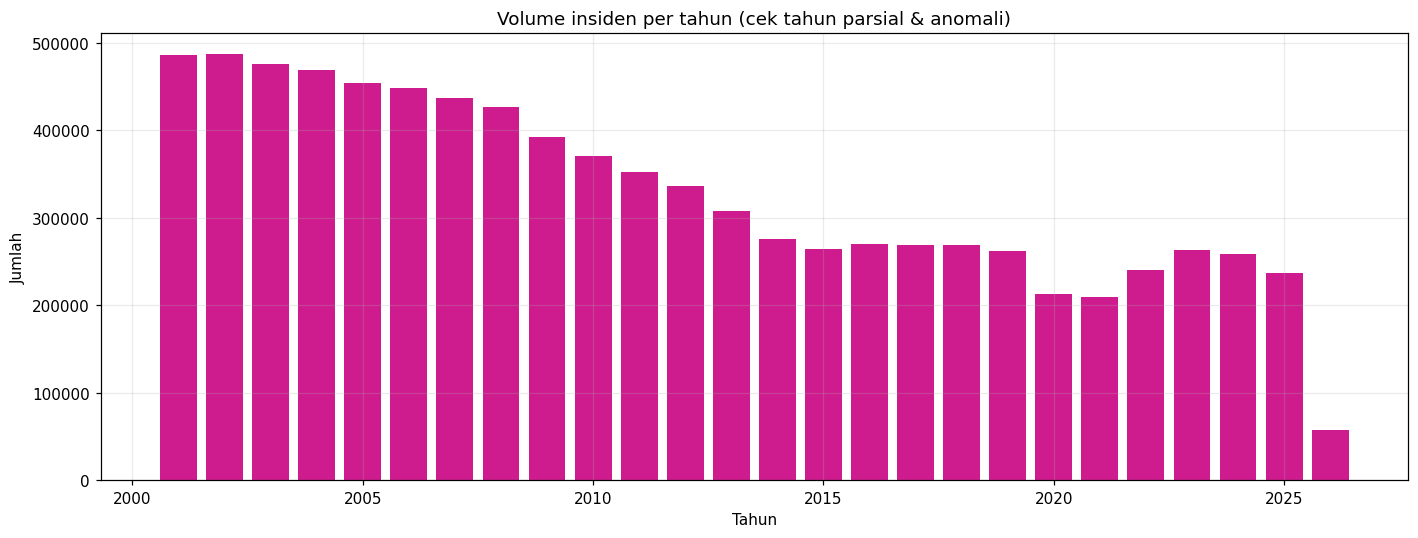

In [12]:
# 4.1 Volume per tahun
by_year_cnt=df['yr'].value_counts().sort_index()
print(by_year_cnt)
plt.figure(figsize=(13,5))
plt.bar(by_year_cnt.index.astype(int), by_year_cnt.values, color=ACCENT)
plt.title('Volume insiden per tahun (cek tahun parsial & anomali)')
plt.xlabel('Tahun'); plt.ylabel('Jumlah'); plt.tight_layout(); plt.show()

Volume menurun konsisten dari ~486 rb (2001) ke titik terendah ~210 rb (2021), lalu naik ringan pada 2022-2024; angka 2026 (57 rb) rendah karena data belum lengkap. Cakupan penuh 25+ tahun ini memberi basis historis kaya untuk pola spasial, sekaligus menegaskan perlunya temporal decay agar kejadian lama tidak dinilai serelevan kejadian terbaru.


In [13]:
# 4.2 Konsistensi Year (kolom) vs tahun dari Date, dan tanggal masa depan
mismatch=int((df['Year'].notna() & (df['Year'] != df['yr'])).sum())
print('Baris dgn kolom Year != tahun(Date):', mismatch)
print('Tanggal setelah Updated On (anomali):', int((df['Date'] > df['Updated On']).sum()))
print('Tanggal NaT:', int(df['Date'].isna().sum()))

Baris dgn kolom Year != tahun(Date): 0
Tanggal setelah Updated On (anomali): 0
Tanggal NaT: 0


**konsistensi tanggal.** Tidak ada satu pun ketidakcocokan antara kolom `Year` dan tahun dari `Date`


## 5. Konsistensi Taksonomi (IUCR vs Primary Type)
IUCR adalah klasifikasi paling stabil. Label Primary Type/Description bisa berubah antar tahun.
Menguji: berapa IUCR yang memetakan ke >1 Primary Type, dan mendeteksi label kembar (mis. CRIM vs CRIMINAL SEXUAL ASSAULT).

In [14]:
# 5.1 IUCR yang punya lebih dari satu label Primary Type
map_n=df.groupby('IUCR', observed=True)['Primary Type'].nunique()
print('IUCR total:', len(map_n), '| IUCR dgn >1 Primary Type:', int((map_n>1).sum()))
bad=map_n[map_n>1].index[:10]
for code_ in bad:
    labs=df.loc[df['IUCR']==code_,'Primary Type'].value_counts().head(3)
    print(f'IUCR {code_}:', dict(labs))

IUCR total: 418 | IUCR dgn >1 Primary Type: 13
IUCR 0261: {'CRIM SEXUAL ASSAULT': np.int64(1615), 'CRIMINAL SEXUAL ASSAULT': np.int64(478)}
IUCR 0262: {'CRIM SEXUAL ASSAULT': np.int64(34), 'CRIMINAL SEXUAL ASSAULT': np.int64(15)}
IUCR 0263: {'CRIM SEXUAL ASSAULT': np.int64(1006), 'CRIMINAL SEXUAL ASSAULT': np.int64(232)}
IUCR 0264: {'CRIM SEXUAL ASSAULT': np.int64(289), 'CRIMINAL SEXUAL ASSAULT': np.int64(79)}
IUCR 0265: {'CRIM SEXUAL ASSAULT': np.int64(4386), 'CRIMINAL SEXUAL ASSAULT': np.int64(1721)}
IUCR 0266: {'CRIM SEXUAL ASSAULT': np.int64(2680), 'CRIMINAL SEXUAL ASSAULT': np.int64(1027)}
IUCR 0271: {'CRIM SEXUAL ASSAULT': np.int64(151), 'CRIMINAL SEXUAL ASSAULT': np.int64(39)}
IUCR 0272: {'CRIM SEXUAL ASSAULT': np.int64(3), 'CRIMINAL SEXUAL ASSAULT': np.int64(2)}
IUCR 0273: {'CRIM SEXUAL ASSAULT': np.int64(176), 'CRIMINAL SEXUAL ASSAULT': np.int64(20)}
IUCR 0274: {'CRIM SEXUAL ASSAULT': np.int64(47), 'CRIMINAL SEXUAL ASSAULT': np.int64(8)}


**inkonsistensi taksonomi.** 13 kode `IUCR` memetakan ke >1 `Primary Type`, dan seluruhnya adalah varian ejaan yang sama (`CRIM SEXUAL ASSAULT` vs `CRIMINAL SEXUAL ASSAULT`). Keputusan: kanonikalisasi `Primary Type` berdasarkan IUCR di tahap preprocessing agar satu kode = satu label.


In [15]:
# 5.2 Rentang tahun kemunculan tiap Primary Type (deteksi label usang/baru)
span=df.groupby('Primary Type', observed=True)['yr'].agg(['min','max','size']).sort_values('size', ascending=False)
span.columns=['tahun_pertama','tahun_terakhir','volume']
print(span)

                                   tahun_pertama  tahun_terakhir   volume
Primary Type                                                             
THEFT                                       2001            2026  1812951
BATTERY                                     2001            2026  1554443
CRIMINAL DAMAGE                             2001            2026   970114
NARCOTICS                                   2001            2026   766981
ASSAULT                                     2001            2026   573910
OTHER OFFENSE                               2001            2026   533160
BURGLARY                                    2001            2026   451173
MOTOR VEHICLE THEFT                         2001            2026   439408
DECEPTIVE PRACTICE                          2001            2026   395718
ROBBERY                                     2001            2026   316790
CRIMINAL TRESPASS                           2001            2026   229312
WEAPONS VIOLATION                     

Seluruh tipe kejahatan volume-tinggi muncul sepanjang 2001-2026 tanpa label yang tiba-tiba hilang atau baru muncul. 


## 6. Integritas Spasial & Outlier
Bounding box Chicago kira-kira lat 41.6..42.1, lon -87.95..-87.5. Memeriksa titik di luar kota dan koordinat (0,0).

In [16]:
# 6.1 Outlier koordinat
geo=df.dropna(subset=['Latitude','Longitude'])
in_box=geo['Latitude'].between(41.6,42.1) & geo['Longitude'].between(-87.95,-87.5)
zero=(geo['Latitude'].abs()<0.01) & (geo['Longitude'].abs()<0.01)
print('Baris berkoordinat      :', len(geo))
print('Di luar bounding box    :', int((~in_box).sum()))
print('Koordinat ~ (0,0)       :', int(zero.sum()))
print(geo[['Latitude','Longitude']].describe().round(4))

Baris berkoordinat      : 8438277
Di luar bounding box    : 149
Koordinat ~ (0,0)       : 0
           Latitude     Longitude
count  8.438277e+06  8.438277e+06
mean   4.184260e+01 -8.767120e+01
std    1.206600e+00  5.638700e+00
min    3.661940e+01 -9.168660e+01
25%    4.176900e+01 -8.771320e+01
50%    4.185670e+01 -8.766550e+01
75%    4.190710e+01 -8.762810e+01
max    4.202290e+01 -8.752450e+01


Dari 8,44 jt baris berkoordinat, hanya 149 titik jatuh di luar bounding box Chicago dan tidak ada koordinat palsu (0,0). 


## 7. Distribusi untuk Skala Target (persiapan pseudo-label)

Sel grid terisi: 746
count       746.0
mean      11311.2
std       12232.3
min           1.0
25%        1670.0
50%        7940.5
75%       16752.8
max      107964.0
dtype: float64
Skewness: 2.02


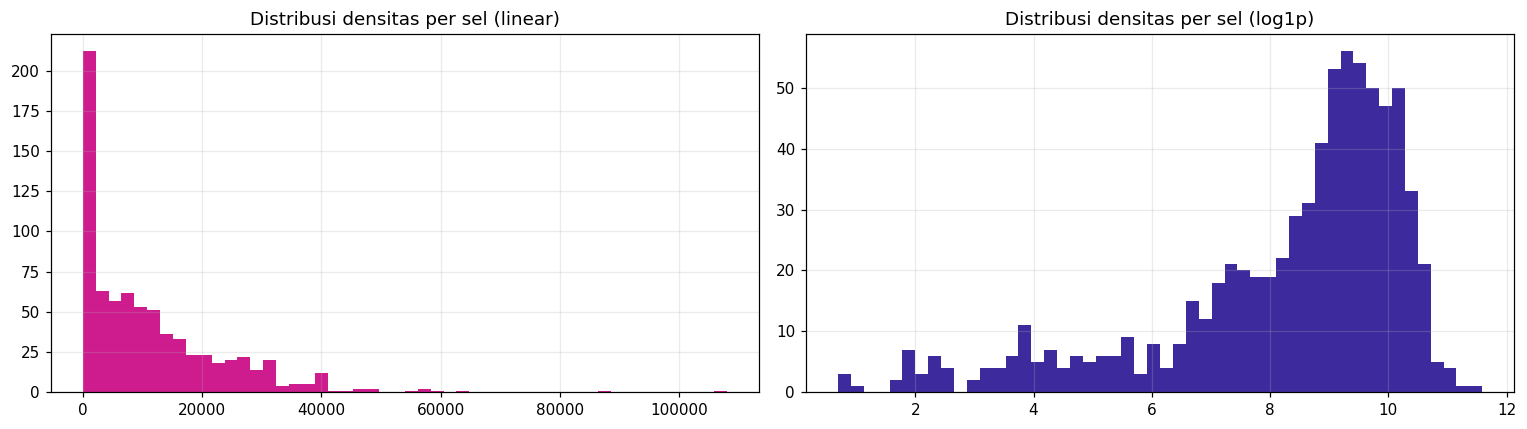

In [17]:
# 7.1 Skewness densitas grid
GRID=0.01
g2=geo[in_box].copy()
g2['glat']=(g2['Latitude']/GRID).round()*GRID
g2['glon']=(g2['Longitude']/GRID).round()*GRID
gc=g2.groupby(['glat','glon']).size()
print('Sel grid terisi:', len(gc))
print(gc.describe().round(1))
print('Skewness:', round(float(gc.skew()),2) if len(gc)>2 else 'n/a')
fig,ax=plt.subplots(1,2,figsize=(14,4))
ax[0].hist(gc.values, bins=50, color=ACCENT); ax[0].set_title('Distribusi densitas per sel (linear)')
ax[1].hist(np.log1p(gc.values), bins=50, color=ACCENT2); ax[1].set_title('Distribusi densitas per sel (log1p)')
plt.tight_layout(); plt.show()

Densitas per sel grid sangat condong ke kanan (skewness 2,02; median ~7.940 vs maks ~107.964). Jika Risk Score dihitung langsung dari jumlah mentah, segelintir sel ekstrem akan mendominasi skala. Implikasi desain: pada pseudo-labeling perlu transformasi penipis ekor + winsorisasi sebelum normalisasi 0-100.


## 8. Ringkasan Diagnostik

In [18]:
summary={
  'baris': len(df),
  'rentang': f"{df['Date'].min()} - {df['Date'].max()}",
  'pct_tanpa_koordinat': round(df['Latitude'].isna().mean()*100,2),
  'pct_ward_missing': round(df['Ward'].isna().mean()*100,2),
  'case_number_ganda(baris)': int(df['Case Number'].duplicated(keep=False).sum()),
  'duplikat_ID': int(df['ID'].duplicated().sum()),
}
for k,v in summary.items(): print(f'{k:28}: {v}')

baris                       : 8534663
rentang                     : 2001-01-01 00:00:00 - 2026-04-11 00:00:00
pct_tanpa_koordinat         : 1.13
pct_ward_missing            : 7.2
case_number_ganda(baris)    : 1125
duplikat_ID                 : 0
